# 10 × 5 STV: MGGG Projection vs. Our Simulation

Reproduces the "Projected number of city council seats" comparison from the
original MGGG-style repo's `ensembles/Analysis.ipynb`
(`df10x5[groups].hist(figsize=(40,4), layout=(1,4), bins=list(range(30)))`),
laid out here as the top row of a 3×4 grid, with two additional rows showing
the same seat-count distributions from our own VoteKit-based election
simulation for the **10 X 5 STV - Asian Bloc Separate** run
(`configs/asian-seperate-bloc.json`) -- one row per voter model
(Plackett-Luce, Bradley-Terry).

All three rows share the same four columns (Asian, Black, Hispanic, White)
and the same `bins=range(30)` x-axis, so each column is a direct before/after
comparison of that group's projected vs. simulated seat count.

This notebook depends on a sibling checkout of the original repo at
`/Users/brocksauvage/Documents/Github/chicago` for `projection/projection_10x5.csv`
-- it isn't part of this repo.

In [1]:
import os
import sys
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
# pipeline/summarize_results.py's functions use bare relative paths (e.g.
# Path("outputs")/..., config["geodata_path"]) that assume cwd is the repo
# root, same as when run.py drives them -- match that here so this notebook
# can call those functions directly instead of re-deriving the same logic.
os.chdir(REPO_ROOT)

from run import load_config
from pipeline.summarize_results import (
    build_summary_dataframe, aggregate_to_plan_level,
    _compute_representation_baselines, _prepare_directories, _slate_baselines,
)
from pipeline.utils.helpers import build_config_settings, add_config_settings_box

# Sibling checkout of the original MGGG-style repo -- not part of this repo,
# referenced only for its precomputed projection CSV.
MGGG_REPO_ROOT = Path("/Users/brocksauvage/Documents/Github/chicago")

GROUPS = ["Asian", "Black", "Hispanic", "White"]
BINS = list(range(30))

## Load the MGGG repo's precomputed 10×5 projection

In [2]:
mggg_10x5 = pd.read_csv(MGGG_REPO_ROOT / "projection" / "projection_10x5.csv")
mggg_10x5[GROUPS].describe()

,Asian,Black,Hispanic,White
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.263660,16.632010,14.833970,18.270360
std,0.504743,1.690143,2.019689,1.889566
min,0.000000,10.000000,7.000000,11.000000
25%,0.000000,15.000000,13.000000,17.000000
50%,0.000000,17.000000,15.000000,18.000000
75%,0.000000,18.000000,16.000000,20.000000
max,5.000000,24.000000,24.000000,26.000000


## Load our own "10 X 5 STV - Asian Bloc Separate" run

In [3]:
config = load_config(str(REPO_ROOT / "configs" / "10x5-stv.json"))
run_name = config["run_name"]
i_cs_turnout = _compute_representation_baselines(config)[1]
results_dir, summary_dir, figs_dir = _prepare_directories(run_name)
df = build_summary_dataframe(config, results_dir, i_cs_turnout)
df_plan = aggregate_to_plan_level(df)

# Slate -> group label, matching GROUPS' naming/order so all three rows share
# the same columns.
SLATE_TO_GROUP = {"A": "Asian", "B": "Black", "H": "Hispanic", "W": "White"}

pl_seats = df_plan[df_plan["mode"] == "slate_pl"]
bt_seats = df_plan[df_plan["mode"] == "slate_bt"]
print(f"Plackett-Luce instances: {len(pl_seats)}, Bradley-Terry instances: {len(bt_seats)}")

# Proportional seats per group: that slate's demographic share of VAP (same
# baseline used for reference lines elsewhere in this project) times the
# total number of council seats -- one value per column, shared across the
# PL/BT rows since it's a population fact, not tied to a voter model.
slate_baselines = _slate_baselines(config)
PROPORTIONAL_SEATS = {
    group: slate_baselines[slate][0] * config["total_seats"]
    for slate, group in SLATE_TO_GROUP.items()
}

# The MGGG projection row uses 2010-census-era precinct boundaries/VAP
# instead of our own 2020-census config -- the ensemble CSVs Projection.ipynb
# actually used are gitignored in that repo and not present here, but the
# same precinct-level VAP columns they were built from are, in its
# shapefiles/chicago_precincts_2012.shp. Computing proportional seats from
# that instead gives the era-appropriate baseline for the 2019 projection
# row specifically, rather than reusing our 2020 numbers there too.
mggg_precincts = gpd.read_file(MGGG_REPO_ROOT / "shapefiles" / "chicago_precincts_2012.shp")
total_vap_2019 = mggg_precincts["VAP"].sum()
VAP_COL_2019 = {"White": "WVAP", "Black": "BVAP", "Hispanic": "HVAP", "Asian": "ASIANVAP"}
PROPORTIONAL_SEATS_2019 = {
    group: mggg_precincts[col].sum() / total_vap_2019 * config["total_seats"]
    for group, col in VAP_COL_2019.items()
}

print("PROPORTIONAL_SEATS (2020, PL/BT rows):", PROPORTIONAL_SEATS)
print("PROPORTIONAL_SEATS_2019 (MGGG row):", PROPORTIONAL_SEATS_2019)

/Users/brocksauvage/Documents/Github/Chicago-City-Council-Reform-2026/.venv/lib/python3.13/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'chicago_precincts_vap_cvap.gpkg': 'chicago_precincts' (default), 'city_boundary'. Specify layer parameter to avoid this warning.
  result = read_func(


Plackett-Luce instances: 500, Bradley-Terry instances: 500
PROPORTIONAL_SEATS (2020, PL/BT rows): {'Asian': 4.018358684872711, 'Black': 14.901303670146968, 'Hispanic': 13.213941915650537, 'White': 17.293243329803516}
PROPORTIONAL_SEATS_2019 (MGGG row): {'White': np.float64(18.337156028814462), 'Black': np.float64(15.411127804658834), 'Hispanic': np.float64(12.574621110419248), 'Asian': np.float64(2.9471649214609834)}


/Users/brocksauvage/Documents/Github/Chicago-City-Council-Reform-2026/.venv/lib/python3.13/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'chicago_precincts_vap_cvap.gpkg': 'chicago_precincts' (default), 'city_boundary'. Specify layer parameter to avoid this warning.
  result = read_func(


## 3×4 comparison grid

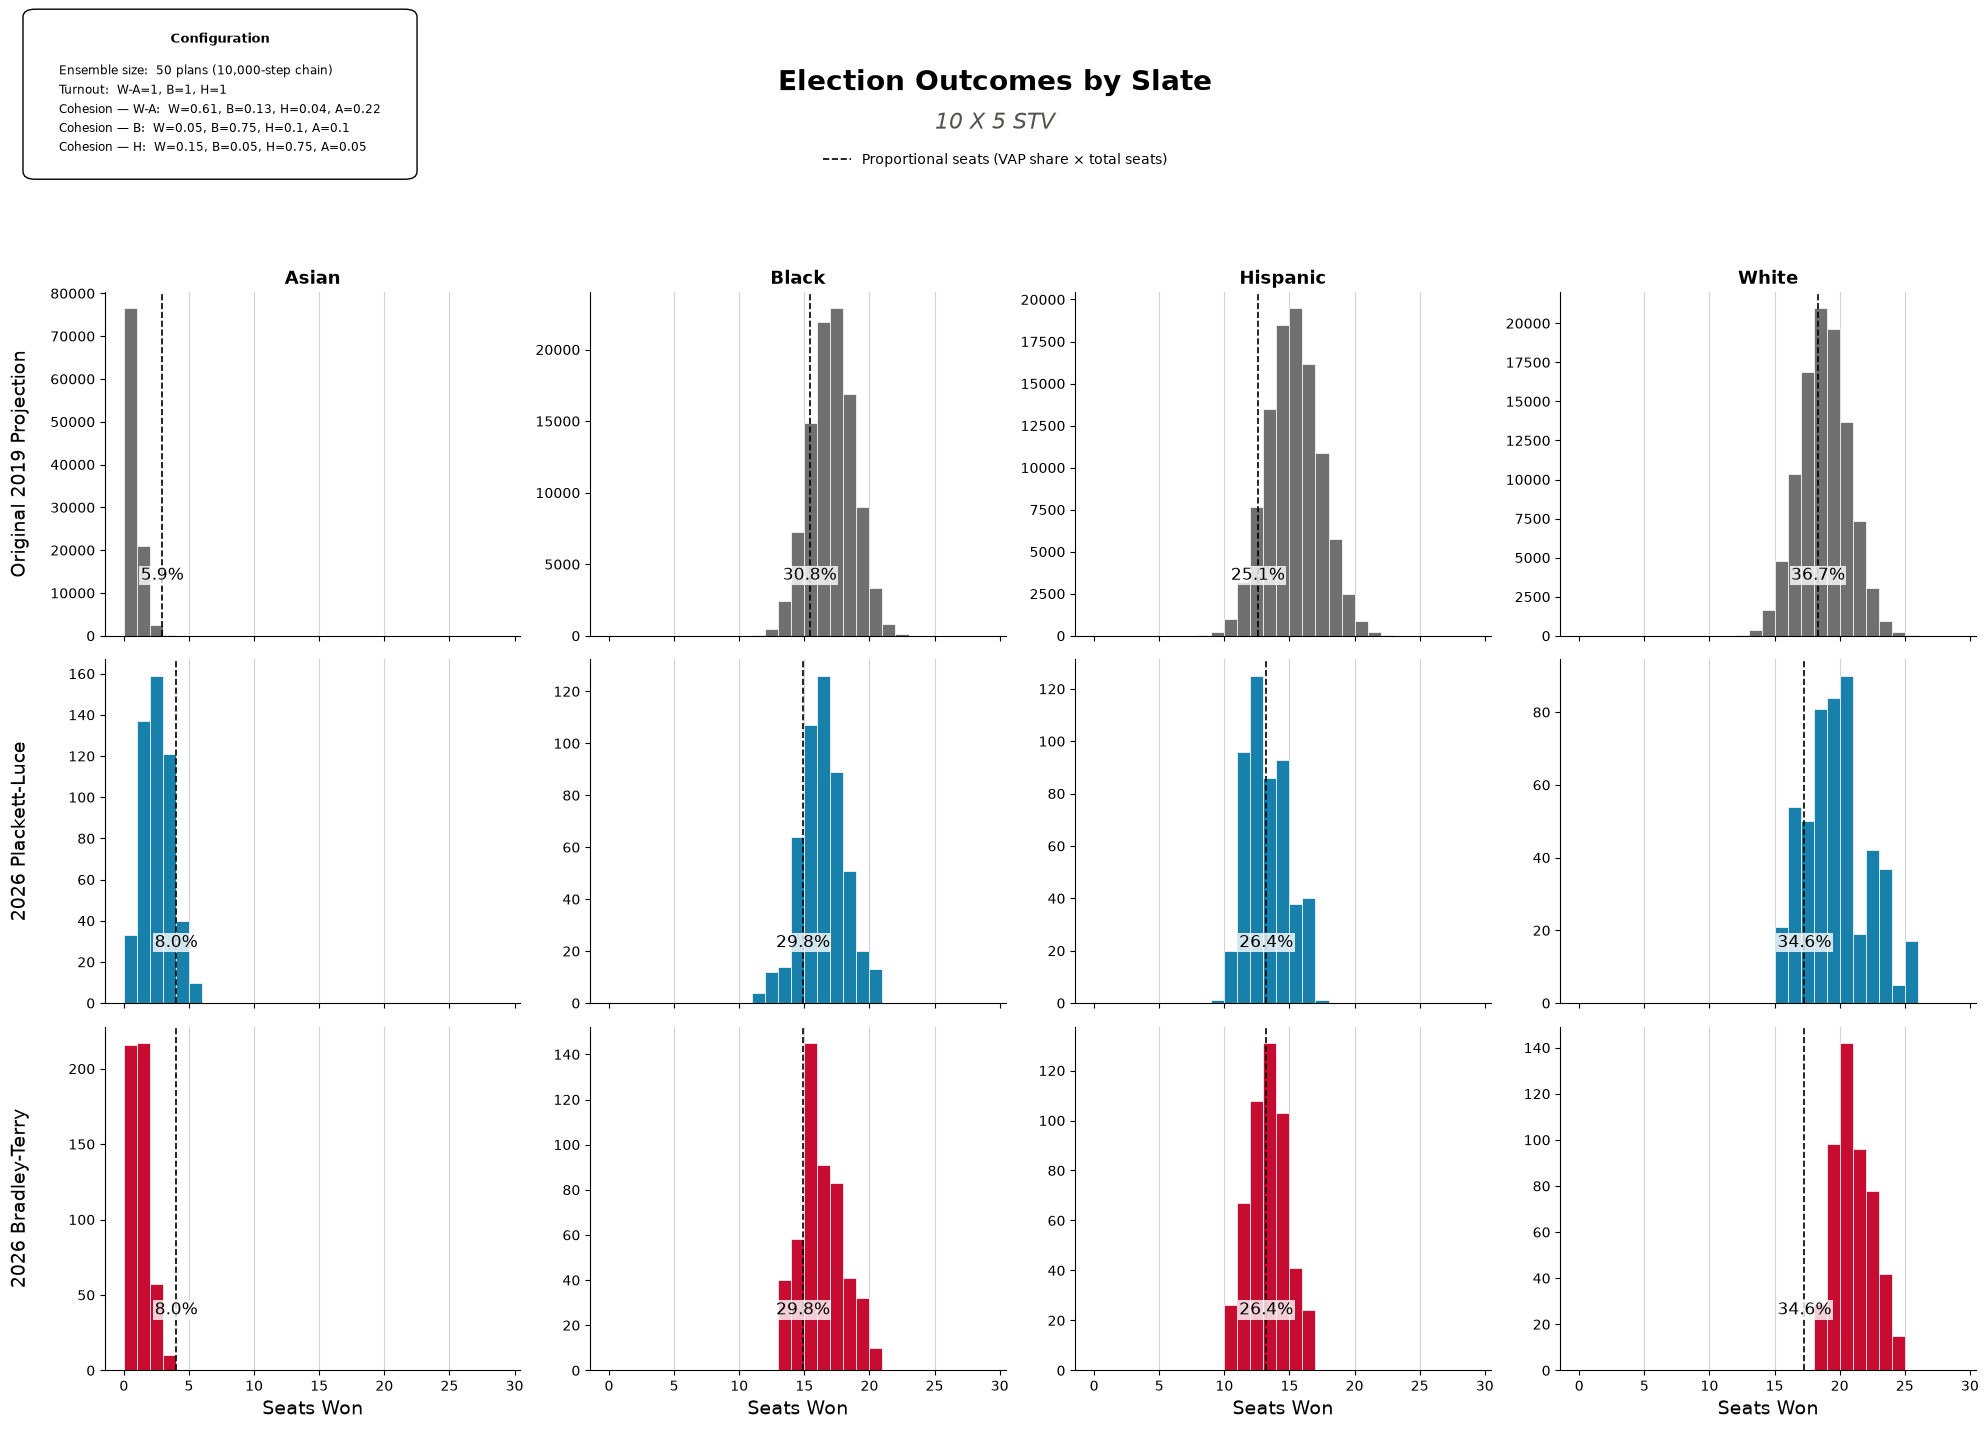

In [7]:
# Same MODE_COLORS used everywhere else in this project's histograms
# (pipeline/summarize_results.py) for slate_pl/slate_bt, plus a grey for the
# MGGG projection row since it isn't one of our voter models.
GREY = "#707070"
BAR_COLORS = {
    "Original 2019 Projection": GREY,
    "2026 Plackett-Luce": "#1780ab",
    "2026 Bradley-Terry": "#C60C30",
}

fig, axes = plt.subplots(3, 4, figsize=(20, 13), sharex=True)

# (row label, data, proportional-seats dict for that row) -- data=None means
# "read straight from mggg_10x5[group]" instead of "seats_<slate>" from one
# of our own mode-filtered subsets. The MGGG row uses its own 2010-census-era
# proportional baseline; the PL/BT rows share our 2020-census one.
ROW_SPECS = [
    ("Original 2019 Projection", None, PROPORTIONAL_SEATS_2019),
    ("2026 Plackett-Luce", pl_seats, PROPORTIONAL_SEATS),
    ("2026 Bradley-Terry", bt_seats, PROPORTIONAL_SEATS),
]

proportional_line = None
for row_idx, (row_label, data, proportional_seats) in enumerate(ROW_SPECS):
    bar_color = BAR_COLORS[row_label]
    for col_idx, group in enumerate(GROUPS):
        ax = axes[row_idx][col_idx]
        if data is None:
            values = mggg_10x5[group]
        else:
            slate = next(s for s, g in SLATE_TO_GROUP.items() if g == group)
            values = data[f"seats_{slate}"]
        ax.hist(values, bins=BINS, color=bar_color, edgecolor="white", linewidth=0.5)

        # Light grey vertical lines every 10 seats, on every panel.
        for x in range(5, BINS[-1], 5):
            ax.axvline(x, color="lightgrey", linewidth=0.8, zorder=0)

        # One proportionality line per column (same x-position in every row):
        # this group's demographic share of VAP times total seats. The MGGG
        # row uses its own era-appropriate baseline (see PROPORTIONAL_SEATS_2019).
        proportional_line = ax.axvline(
            proportional_seats[group], color="black", linestyle="--", linewidth=1.2, zorder=3,
        )

        # Percentage label for that line -- placed at a fixed height (axes
        # fraction, via get_xaxis_transform) rather than a fixed y-value, since
        # each row's y-scale differs wildly (MGGG row reaches ~80,000, PL/BT
        # rows only reach ~200).
        share_pct = proportional_seats[group] / config["total_seats"] * 100
        ax.text(
            proportional_seats[group], 0.2, f"{share_pct:.1f}%",
            transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=12,
            color="black", bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1),
        )

        if row_idx == 0:
            ax.set_title(group, fontsize=13, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(row_label, fontsize=14, labelpad=15)
        if row_idx == len(ROW_SPECS) - 1:
            ax.set_xlabel("Seats Won", fontsize=14)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

# Row labels have very different tick-label widths (80,000 vs. ~200), which
# otherwise pushes each ylabel a different distance from the figure edge;
# align_ylabels pins them all to the same x position regardless.
fig.align_ylabels(axes[:, 0])

fig.suptitle(
    "Election Outcomes by Slate",
    fontsize=20, fontweight="bold", y=1.05,
)
fig.text(
    0.5, 1.0, "10 X 5 STV",
    ha="center", va="bottom", fontsize=16, color="#52514e", style="italic",
)

fig.legend(
    handles=[proportional_line], labels=["Proportional seats (VAP share × total seats)"],
    loc="upper center", bbox_to_anchor=(0.5, 0.995), ncol=1, frameon=False, fontsize=10,
)

# Standardized settings box (see pipeline/utils/helpers.py) -- same style meant
# to be reused on every simulation visualization, not just this one.
add_config_settings_box(fig, build_config_settings(config))

# rect leaves extra headroom below the settings box/legend before the subplot
# grid starts, since tight_layout doesn't know about those manually-placed
# figure-level artists on its own.
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()